In [1]:
# Forensic Fraud Detection Pipeline
# Stage 1: Statistical Investigation → Stage 2: Anomaly Detection → Stage 3: Risk Scoring

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.fraud.data_loader import load, impute, feature_matrix, NUMERIC_FEATURES
from src.fraud.statistical_investigation import (
    univariate_summary,
    benfords_law_test,
    missing_value_heatmap,
    correlation_heatmap,
    label_split_boxplots,
    normality_tests,
)
from src.scoring import compute_risk_score, create_pseudo_labels, compute_percentage_fraud
from src.pipeline import run_full_pipeline

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

---
## Stage 1 — Statistical Investigation

We begin with forensic statistics: surfacing suspicious signal in the raw data **without touching the fraud label**. The goal is to understand the shape of the data, identify manipulation patterns, and flag features that warrant closer scrutiny.

In [2]:
# Load raw data — label column exists but is NOT used until post-hoc evaluation
df_raw = load()
print(f"Dataset: {df_raw.shape[0]:,} transactions × {df_raw.shape[1]} columns")
print(f"Fraud prevalence (held-out): {df_raw['is_fraud'].mean():.1%}")
df_raw.head()

Dataset: 7,000 transactions × 13 columns
Fraud prevalence (held-out): 10.3%


,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
0,161.363691,3.0,0.0,2.0,18.000000,2.0,26.539742,1.0,48.403937,0.0,0.0,3.718296,0
1,116.202851,1.0,1.0,4.0,26.285818,2.0,50.714402,NaN,76.144979,0.0,0.0,4.951272,0
2,1.000000,2.0,0.0,5.0,18.000000,NaN,9.467935,0.0,67.600316,0.0,0.0,4.556043,0
3,48.780618,2.0,0.0,3.0,44.471190,NaN,41.077068,0.0,94.825526,0.0,0.0,6.918437,0
4,NaN,3.0,0.0,4.0,38.733609,8.0,NaN,2.0,100.000000,0.0,1.0,5.535335,1


### 1.1 Missing Value Analysis

Correlated missingness across features is a forensic signal — it can indicate that records were selectively tampered with or that a data extraction process dropped fields non-randomly (MNAR).

In [3]:
print("Missing values per feature:")
missing = df_raw[NUMERIC_FEATURES].isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
pd.DataFrame({"count": missing, "%": missing_pct}).query("count > 0").sort_values("%", ascending=False)

Missing values per feature:


,count,%
velocity_score,1050,15.0
customer_age,840,12.0
distance_from_home,700,10.0
network_quality,630,9.0
transaction_amount,560,8.0
prev_transactions,490,7.0
hour_of_day,350,5.0
device_type,280,4.0
num_items,210,3.0
is_first_transaction,210,3.0


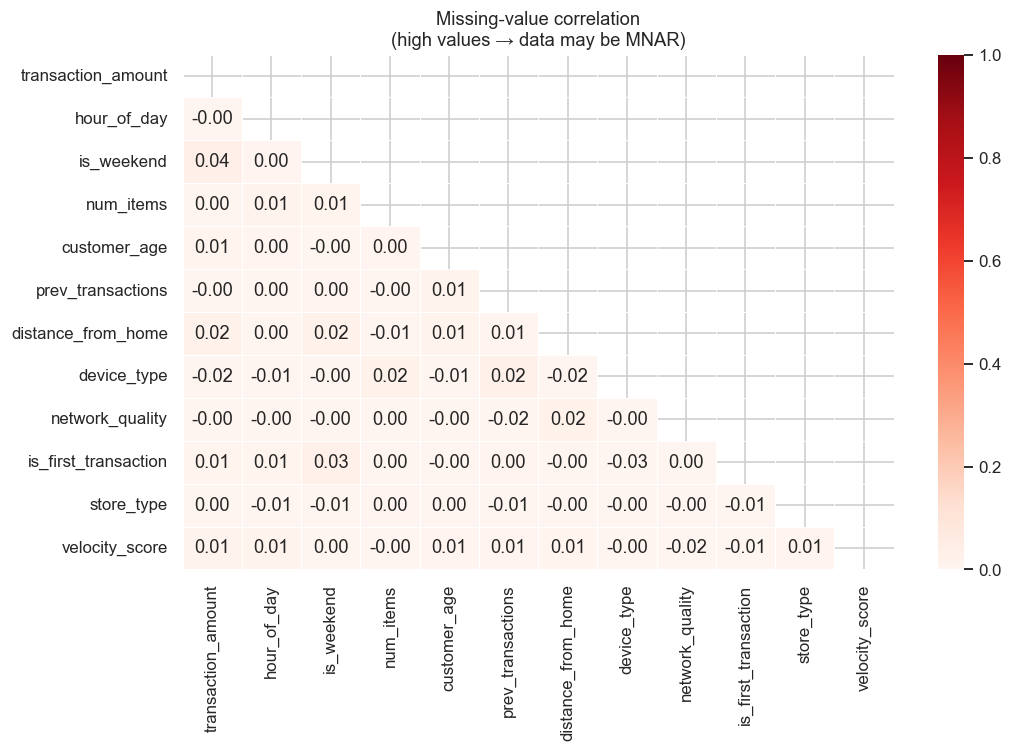

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))
missing_value_heatmap(df_raw[NUMERIC_FEATURES], ax=ax)
plt.tight_layout()
plt.show()

### 1.2 Univariate Summary

Features with extreme skewness (|skew| > 2), high kurtosis (> 7), or >10% missingness are flagged — these are the distributions most likely to contain manipulated or anomalous records.

In [5]:
summary = univariate_summary(df_raw, NUMERIC_FEATURES)
summary.style.apply(
    lambda col: ["background-color: #ffe0e0" if v else "" for v in col],
    subset=["forensic_flag"]
)

,n_valid,missing_%,mean,std,min,p25,p50,p75,max,iqr,skewness,kurtosis,forensic_flag
feature,,,,,,,,,,,,,
transaction_amount,6440,8.000000,100.015000,49.091000,1.000000,65.712000,99.482000,132.898000,296.312000,67.186000,0.163000,-0.190000,False
hour_of_day,6650,5.000000,2.201000,0.678000,1.000000,2.000000,2.000000,3.000000,3.000000,1.000000,-0.270000,-0.847000,False
is_weekend,6860,2.000000,0.109000,0.311000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.516000,4.334000,True
num_items,6790,3.000000,2.977000,1.712000,0.000000,2.000000,3.000000,4.000000,13.000000,2.000000,0.611000,0.537000,False
customer_age,6160,12.000000,36.201000,13.284000,18.000000,25.244000,35.361000,45.500000,80.000000,20.256000,0.433000,-0.478000,True
prev_transactions,6510,7.000000,4.458000,4.882000,0.000000,1.000000,3.000000,6.000000,40.000000,5.000000,1.930000,5.226000,False
distance_from_home,6300,10.000000,24.831000,24.315000,0.004000,7.387000,17.321000,34.858000,224.700000,27.471000,1.923000,5.513000,False
device_type,6720,4.000000,0.699000,0.777000,0.000000,0.000000,1.000000,1.000000,2.000000,1.000000,0.579000,-1.120000,False
network_quality,6370,9.000000,74.095000,18.004000,0.477000,61.587000,75.306000,88.254000,100.000000,26.667000,-0.416000,-0.388000,False


### 1.3 Benford's Law — Transaction Amount

In naturally occurring financial data, the leading digit of transaction amounts should follow Benford's distribution (digit 1 appears ~30% of the time, digit 9 ~5%). A significant deviation signals potential fabrication or systematic manipulation of amounts.

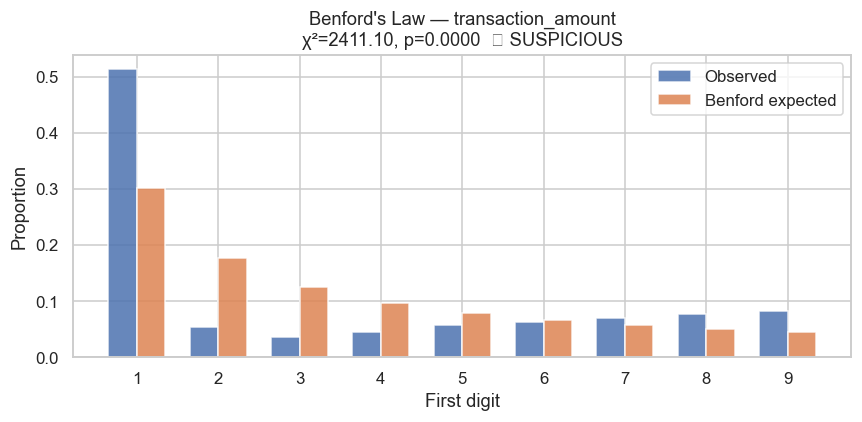

Chi-square statistic : 2411.1037
p-value              : 0.0
Suspicious           : True


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
result = benfords_law_test(df_raw["transaction_amount"], ax=ax)
plt.tight_layout()
plt.show()

print(f"Chi-square statistic : {result['chi2']}")
print(f"p-value              : {result['p_value']}")
print(f"Suspicious           : {result['suspicious']}")

### 1.4 Normality Tests

Most fraud detection anomaly models (Isolation Forest, LOF) are distribution-agnostic, but knowing which features are highly non-normal informs how much we should trust z-score-based outlier rules.

In [7]:
normality_tests(df_raw, NUMERIC_FEATURES)

,test,statistic,p_value,normal
feature,,,,
transaction_amount,D'Agostino-Pearson,34.2973,0.000000,False
hour_of_day,D'Agostino-Pearson,512.6928,0.000000,False
is_weekend,D'Agostino-Pearson,2478.1554,0.000000,False
num_items,D'Agostino-Pearson,355.1213,0.000000,False
customer_age,D'Agostino-Pearson,239.0734,0.000000,False
prev_transactions,D'Agostino-Pearson,1897.5889,0.000000,False
distance_from_home,D'Agostino-Pearson,1947.2955,0.000000,False
device_type,D'Agostino-Pearson,2874.9673,0.000000,False
network_quality,D'Agostino-Pearson,184.8066,0.000000,False


### 1.5 Feature Correlation Matrix

Strongly correlated features can double-weight certain signals in an anomaly model. Features that are uncorrelated with everything else are candidates for being the most discriminative fraud signals.

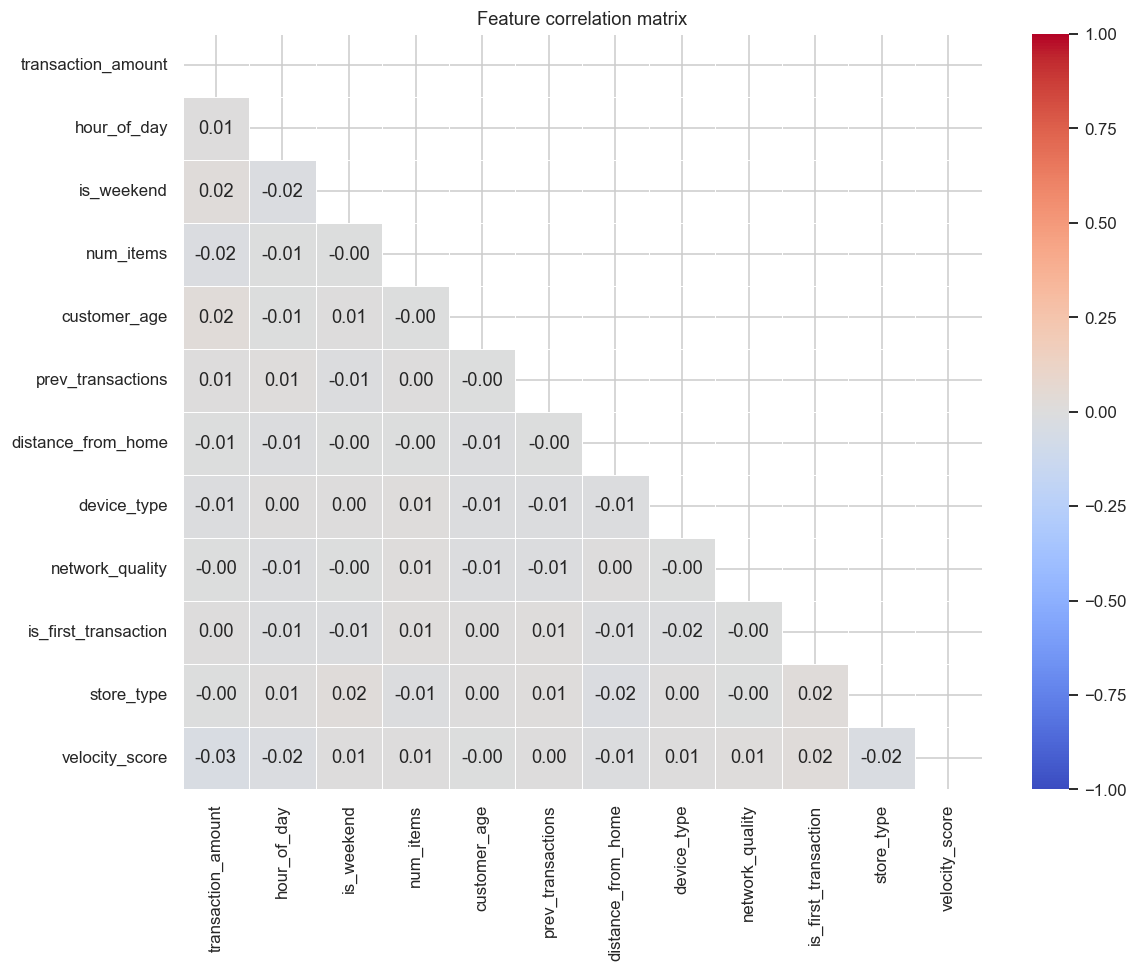

In [8]:
fig, ax = plt.subplots(figsize=(11, 9))
correlation_heatmap(df_raw, NUMERIC_FEATURES, ax=ax)
plt.tight_layout()
plt.show()

---
## Stage 2 — Anomaly Detection

With a clear picture of the data's statistical properties, we now fit an **Isolation Forest** on the full imputed feature matrix. This is entirely unsupervised — the fraud label is not used.

Isolation Forest works by randomly partitioning the feature space. Anomalous points (potential fraud) are isolated with fewer splits than normal points, producing a lower anomaly score.

In [9]:
from sklearn.ensemble import IsolationForest

X, _ = feature_matrix(impute(df_raw))

model = IsolationForest(contamination=0.103, random_state=42)
model.fit(X)

raw_scores = model.decision_function(X)
print(f"Score range  : [{raw_scores.min():.4f}, {raw_scores.max():.4f}]")
print(f"Score std    : {raw_scores.std():.4f}")
print(f"Transactions flagged as anomalous: {(model.predict(X) == -1).sum():,}")

Score range  : [-0.1283, 0.1537]
Score std    : 0.0477
Transactions flagged as anomalous: 721


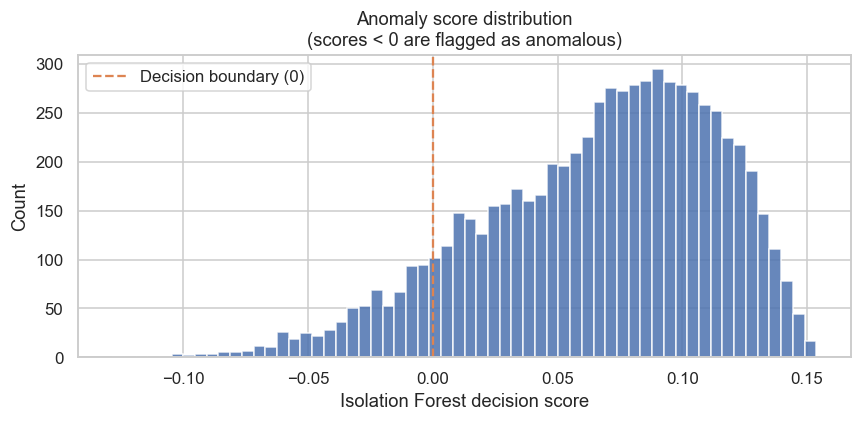

In [10]:
# Distribution of raw anomaly scores
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(raw_scores, bins=60, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(0, color="#DD8452", linewidth=1.5, linestyle="--", label="Decision boundary (0)")
ax.set_xlabel("Isolation Forest decision score")
ax.set_ylabel("Count")
ax.set_title("Anomaly score distribution\n(scores < 0 are flagged as anomalous)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Stage 3 — Risk Scoring

The raw anomaly scores are inverted and normalised to **[0, 1]** to produce an interpretable risk score. We then bucket scores into three tiers calibrated to the ~10% base rate:

| Tier | Label | Threshold | Meaning |
|------|-------|-----------|---------|
| Low | 0 | Bottom 60% | Normal behaviour |
| Medium | 1 | 60th–90th percentile | Worth monitoring |
| High | 2 | Top 10% | Prioritise for review |

In [11]:
# Run the full pipeline
results = run_full_pipeline(df_raw)

print(f"Estimated fraud rate : {compute_percentage_fraud(df_raw):.1f}%")
print(f"Risk score range     : [{results['risk_score'].min():.4f}, {results['risk_score'].max():.4f}]")

# Tier distribution
labels = create_pseudo_labels(df_raw)
print("\nTier distribution:")
print(labels.value_counts().sort_index().rename({0: "Low (0)", 1: "Medium (1)", 2: "High (2)"}).to_string())

Estimated fraud rate : 10.0%
Risk score range     : [0.0000, 1.0000]

Tier distribution:
Low (0)       4200
Medium (1)    2100
High (2)       700


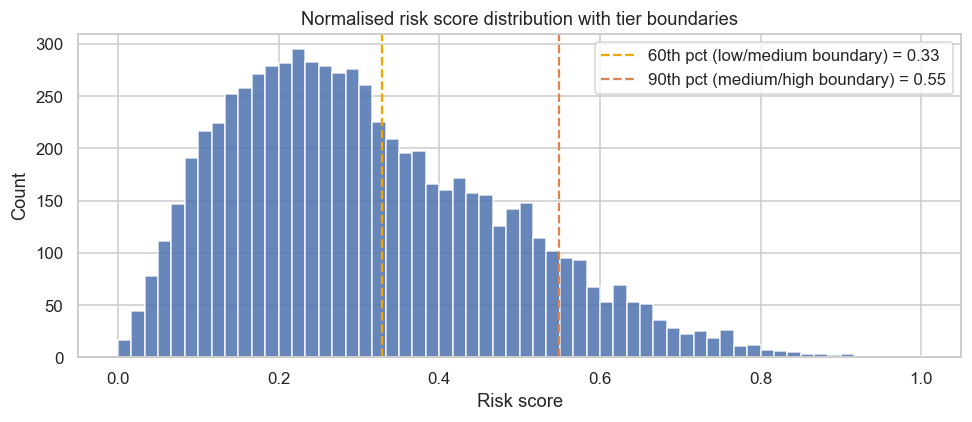

In [12]:
# Risk score distribution with tier boundaries
scores = results["risk_score"]
p60 = scores.quantile(0.60)
p90 = scores.quantile(0.90)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(scores, bins=60, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(p60, color="#f0a500", linewidth=1.5, linestyle="--", label=f"60th pct (low/medium boundary) = {p60:.2f}")
ax.axvline(p90, color="#DD8452", linewidth=1.5, linestyle="--", label=f"90th pct (medium/high boundary) = {p90:.2f}")
ax.set_xlabel("Risk score")
ax.set_ylabel("Count")
ax.set_title("Normalised risk score distribution with tier boundaries")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Top 10 highest-risk transactions
print("Top 10 highest-risk transactions:")
results.sort_values("risk_score", ascending=False).head(10)[
    ["transaction_amount", "velocity_score", "distance_from_home",
     "customer_age", "prev_transactions", "risk_score"]
]

Top 10 highest-risk transactions:


,transaction_amount,velocity_score,distance_from_home,customer_age,prev_transactions,risk_score
4026,165.163902,9.470096,7.202573,35.075001,25.0,1.000000
5395,39.985180,NaN,147.792434,34.699403,11.0,0.975977
240,106.208784,0.543421,22.415949,18.000000,18.0,0.944297
6237,34.759155,9.704750,16.337504,18.000000,7.0,0.925038
6576,70.536417,6.958874,121.760272,NaN,0.0,0.916281
926,51.789996,NaN,120.401870,42.166831,0.0,0.912286
5437,NaN,3.677581,NaN,31.993835,40.0,0.902401
5994,97.170576,3.993103,164.312746,18.000000,0.0,0.884395
2774,141.270817,6.029412,107.653250,50.317076,1.0,0.883918
1640,40.166720,6.073651,98.241574,24.289365,10.0,0.872186


---
## Post-hoc Evaluation

The fraud label was held out for the entire pipeline. We now use it **only** to evaluate how well the unsupervised risk score recovers the true fraud signal — this is forensic validation, not model training.

In [14]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_true = df_raw["is_fraud"]
y_score = results["risk_score"]

auc_roc = roc_auc_score(y_true, y_score)
auc_pr  = average_precision_score(y_true, y_score)

print(f"AUC-ROC  : {auc_roc:.4f}  (0.5 = random, 1.0 = perfect)")
print(f"AUC-PR   : {auc_pr:.4f}   (baseline = {y_true.mean():.3f} = fraud prevalence)")

AUC-ROC  : 0.5156  (0.5 = random, 1.0 = perfect)
AUC-PR   : 0.1130   (baseline = 0.103 = fraud prevalence)


In [15]:
# Fraud capture rate by tier — what % of actual frauds land in each tier?
eval_df = df_raw[["is_fraud"]].copy()
eval_df["risk_tier"] = labels.values
eval_df["risk_score"] = results["risk_score"].values

tier_summary = eval_df.groupby("risk_tier").agg(
    transactions=("is_fraud", "count"),
    actual_frauds=("is_fraud", "sum"),
    fraud_rate=("is_fraud", "mean"),
).rename(index={0: "Low", 1: "Medium", 2: "High"})
tier_summary["fraud_rate"] = tier_summary["fraud_rate"].map("{:.1%}".format)
tier_summary["fraud_capture_%"] = (
    eval_df[eval_df["risk_tier"] == 2]["is_fraud"].sum() / y_true.sum() * 100
)
print("Fraud capture rate in High tier: "
      f"{eval_df[eval_df['risk_tier']==2]['is_fraud'].sum() / y_true.sum():.1%} of all frauds")
tier_summary

Fraud capture rate in High tier: 10.7% of all frauds


,transactions,actual_frauds,fraud_rate,fraud_capture_%
risk_tier,,,,
Low,4200,408,9.7%,10.679612
Medium,2100,236,11.2%,10.679612
High,700,77,11.0%,10.679612


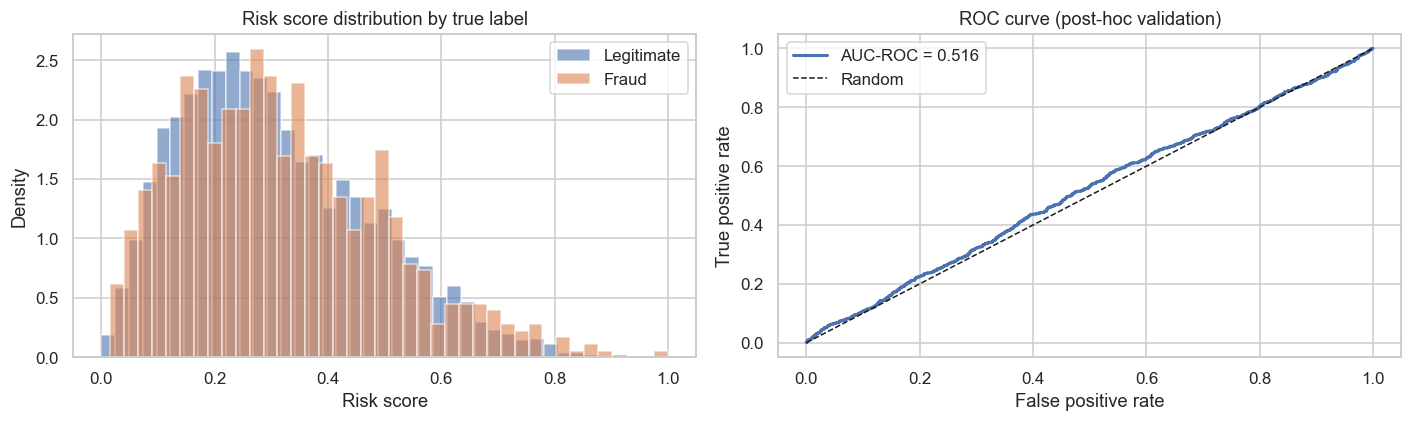

In [16]:
# Risk score distribution split by actual fraud label (post-hoc only)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# KDE by label
for label_val, color, name in [(0, "#4C72B0", "Legitimate"), (1, "#DD8452", "Fraud")]:
    subset = results.loc[df_raw["is_fraud"] == label_val, "risk_score"]
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
axes[0].set_xlabel("Risk score")
axes[0].set_ylabel("Density")
axes[0].set_title("Risk score distribution by true label")
axes[0].legend()

# ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_true, y_score)
axes[1].plot(fpr, tpr, color="#4C72B0", lw=2, label=f"AUC-ROC = {auc_roc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve (post-hoc validation)")
axes[1].legend()

plt.tight_layout()
plt.show()

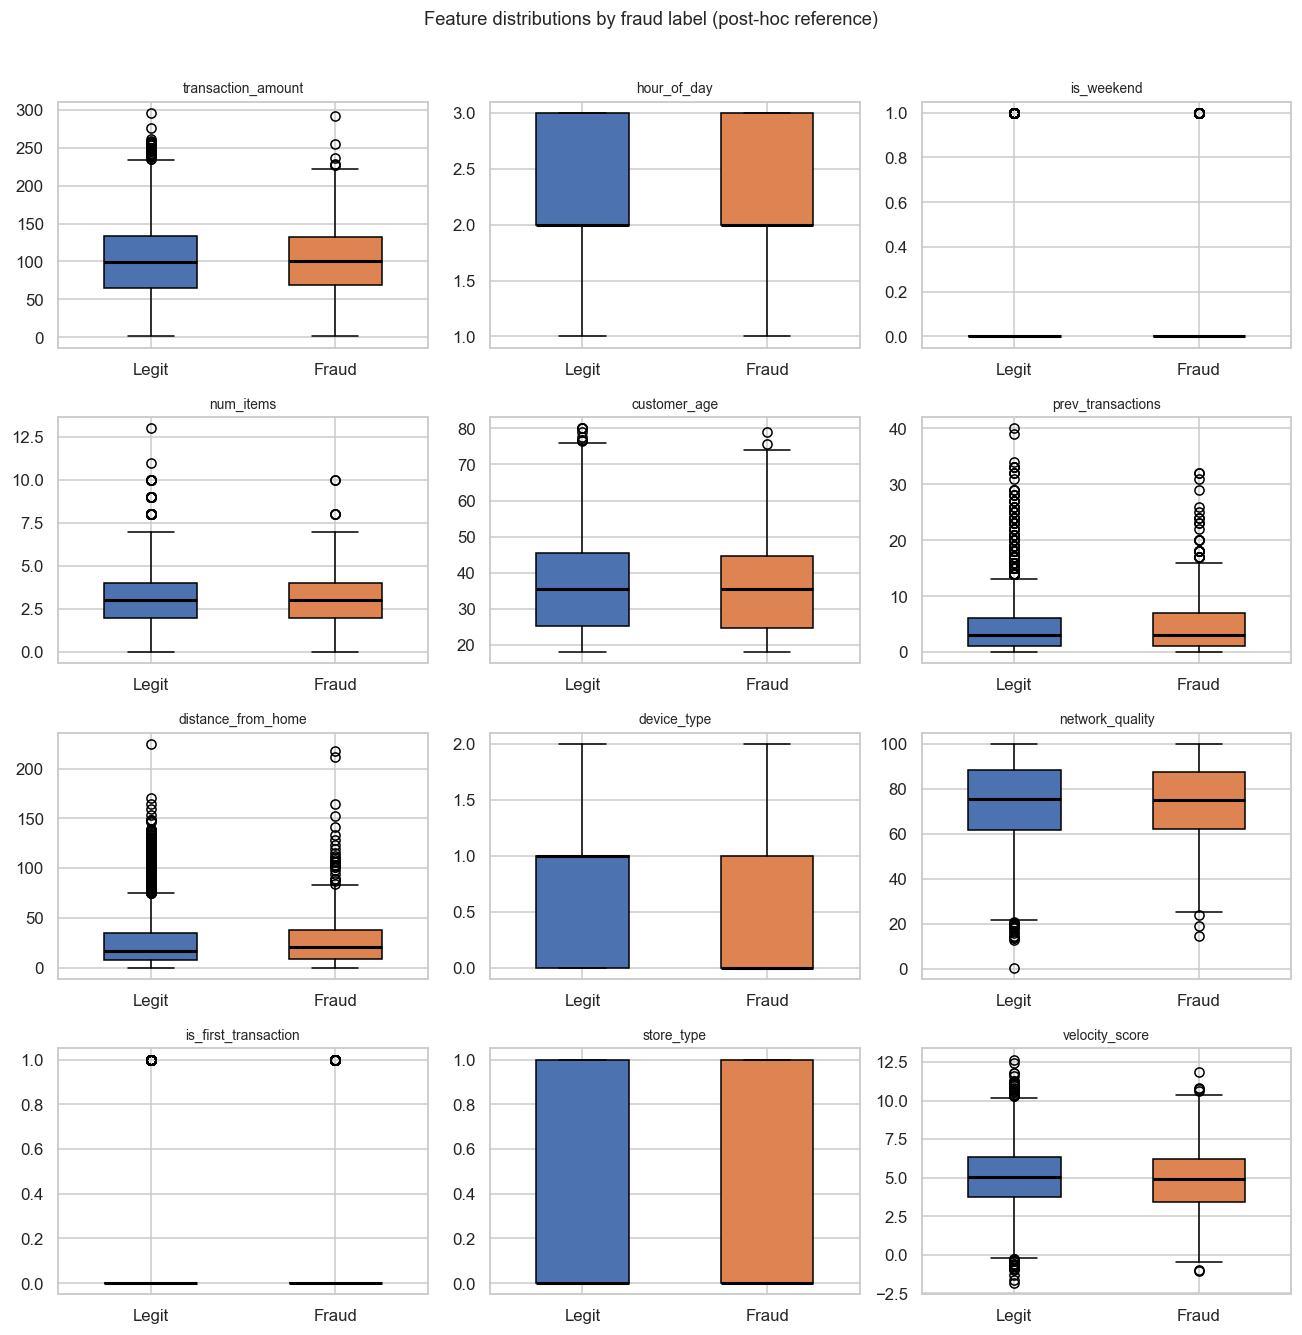

In [17]:
# Feature distributions split by fraud label — post-hoc reference only
fig = label_split_boxplots(df_raw, NUMERIC_FEATURES)
plt.show()